In [ ]:
## House Price Prediction
I built a regression model to predict house prices based on features like area, bedrooms, and location.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn tools for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
# Load dataset
df = pd.read_csv('C:/Users/AR/OneDrive/Desktop/python project/House Price Prediction Dataset.csv')
# Preview first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [30]:
## Data Preprocessing
#Clean the dataset, handle missing values, and convert categorical features into numeric format.

In [12]:
# Check for missing values
df.isnull().sum()

# Drop rows with missing values (if any)
df = df.dropna()

# Convert categorical features to numerical using one-hot encoding
categorical_features = ['Location', 'Condition', 'Garage']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Preview processed data
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [32]:
## Feature Selection & Train-Test Split
#Separating the features and target variable, then spliting the dataset into training and testing sets.

In [16]:
# Features (X) and target (y)
X = df.drop("Price", axis=1)  # all columns except Price
y = df["Price"]               # target variable

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
## Model Training & Prediction
#Train a Linear Regression model and predict house prices on the test set.

In [20]:
# Initialize Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

In [36]:
## Model Evaluation
#Evaluating the model using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [24]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 242867.44926338628
Root Mean Squared Error (RMSE): 279785.21069002635


In [38]:
## Visualization
#Comparing actual vs predicted house prices using a scatter plot.

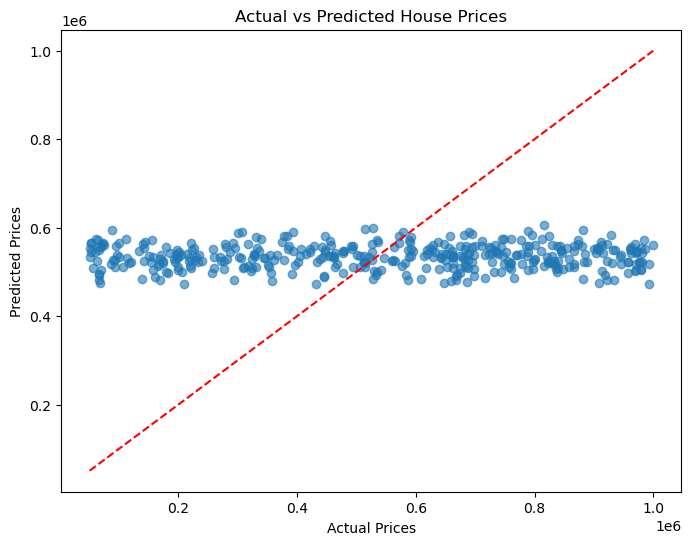

In [28]:
plt.figure(figsize=(8,6))

# Scatter plot of actual vs predicted prices
plt.scatter(y_test, y_pred, alpha=0.6)

# Red dashed line represents perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
# Conclusion
The Linear Regression model predicts house prices reasonably well.  
Features like Area, Bedrooms, and Location have a strong impact on pricing.  
Future improvements can include advanced models like Gradient Boosting or Random Forest for higher accuracy.